# Water Crystal classification

Much of the earth’s surface is covered by water. As was pointed out in the 2020 edition of the World Water Development Report, climate change challenges the sustainability of global water resources, so it is important to monitor the quality of water to preserve sustainable water resources. Quality of water can be related to the structure of water crystal, the solid-state of water, so methods to understand water crystals can help to improve water quality. As a first step, a water crystal exploratory analysis has been initiated with the cooperation with the Emoto Peace Project (EPP). The 5K EPP dataset has been created as the first world-wide small dataset of water crystals. Our research focused on reducing the inherent limitations when fitting machine learning models to the 5K EPP dataset. One major result is the classification of water crystals and how to split our small dataset into several related groups. Using the 5K EPP dataset of human observations and past research on snow crystal classification, we created a simple set of visual labels to identify water crystal shapes, in 13 categories. A deep learning-based method has been used to automatically do the classification task with a subset of the label dataset. The classification achieved high accuracy when using a fine-tuning technique.

## Dataset

The 5K EPP Dataset includes 5007 photos of water crystaks classified in 13 categories. This dataset was created under the leaderhip of Prof. Masaru Emoto.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
import datasets.epp_dataset
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime
from collections import defaultdict
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import os

# Set the log level to only display errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

(train_ds, test_ds, validation_ds), metadata = tfds.load(
    'epp',
    split=['train', 'test', 'validation'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

num_classes = metadata.features['label'].num_classes

print(f"Number of classes: {num_classes}")
print(f"Class names: {metadata.features['label'].names}")

2024-08-06 18:14:25.588653: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-06 18:14:25.600417: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-06 18:14:25.603611: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-06 18:14:25.613153: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-06 18:14:26.294999: W tensorflow/compiler/tf2

Number of classes: 13
Class names: ['microparticule', 'simple_plate', 'fan_like_plate', 'dentrite_plate', 'fern_like_dentrite_plate', 'column_square', 'singular_irregular', 'cloud_particle', 'combinations', 'double_plate', 'multiple_columns_squares', 'multiple_irregulars', 'undefined']


## Image example

2024-08-06 18:14:36.215554: W tensorflow/core/kernels/data/cache_dataset_ops.cc:913] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-08-06 18:14:36.222265: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


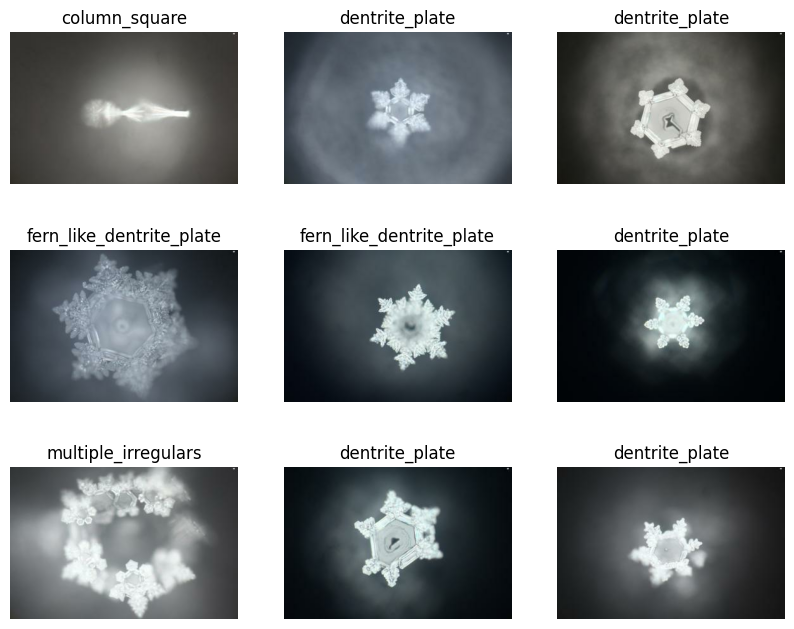

In [3]:
get_label_name = metadata.features['label'].int2str

plt.figure(figsize=(10, 8))

i = 0
for image, label in train_ds.take(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(get_label_name(label))
    plt.axis("off")

    i += 1

## Visualise the distribution

2024-08-06 18:14:39.368335: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


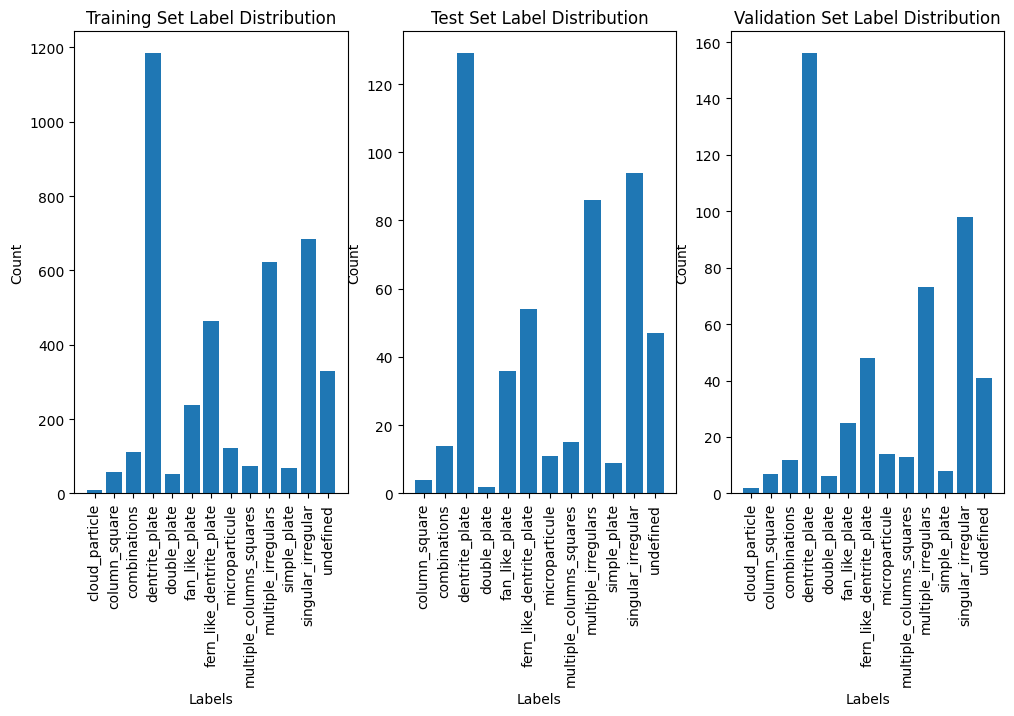

In [4]:
label_names = metadata.features['label'].names

# Function to extract labels and count their occurrences
def get_label_distribution(dataset):
    label_counts = defaultdict(int)
    for _, label in dataset:
        label_counts[get_label_name(label)] += 1

    return label_counts

# Get label distributions for training and test datasets
train_label_distribution = get_label_distribution(train_ds)
test_label_distribution = get_label_distribution(test_ds)
validation_label_distribution = get_label_distribution(validation_ds)

# Sort the distributions by label ID
train_label_distribution = dict(sorted(train_label_distribution.items()))
test_label_distribution = dict(sorted(test_label_distribution.items()))
validation_label_distribution = dict(sorted(validation_label_distribution.items()))

# Plotting the label distributions
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

ax[0].bar(train_label_distribution.keys(), train_label_distribution.values())
ax[0].set_title('Training Set Label Distribution')
ax[0].set_xlabel('Labels')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=90)

ax[1].bar(test_label_distribution.keys(), test_label_distribution.values())
ax[1].set_title('Test Set Label Distribution')
ax[1].set_xlabel('Labels')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis='x', rotation=90)

ax[2].bar(validation_label_distribution.keys(), validation_label_distribution.values())
ax[2].set_title('Validation Set Label Distribution')
ax[2].set_xlabel('Labels')
ax[2].set_ylabel('Count')
ax[2].tick_params(axis='x', rotation=90)

plt.show()

## Preprocess dataset

In [5]:
def normalize_label(image, label):
  return image, tf.one_hot(label, num_classes)

train_ds = train_ds.map(normalize_label, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.shuffle(metadata.splits['train'].num_examples)
train_ds = train_ds.batch(32)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(normalize_label, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32)
test_ds = test_ds.cache()
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

validation_ds = validation_ds.map(normalize_label, num_parallel_calls=tf.data.AUTOTUNE)
validation_ds = validation_ds.batch(32)
validation_ds = validation_ds.cache()
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

## Create and execute the model (without active learning)

In [6]:
# Get label distributions for training and test datasets
label_counts = defaultdict(int)
for _, label in train_ds.unbatch():
    label_counts[np.argmax(label)] += 1

# Calculate class weights
class_weight = {k: v / sum(label_counts.values()) for k, v in label_counts.items()}

data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip(),
  tf.keras.layers.RandomRotation(0.025),
  tf.keras.layers.RandomTranslation(0.025, 0.025),
  tf.keras.layers.RandomZoom(0.025)
])

preprocess_input = tf.keras.applications.inception_resnet_v2.preprocess_input

base_model = tf.keras.applications.InceptionResNetV2(
  input_shape=(240, 360, 3),
  include_top=False
)
base_model.trainable = True
print("Number of layers in the base model: ", len(base_model.layers)) # Number of layers: 780
for layer in base_model.layers[:770]:                                 # Freeze: 0 --> 770, Unfreeze: 771 --> 780
  layer.trainable = False

global_max_layer = tf.keras.layers.GlobalMaxPool2D()
prediction_layer = tf.keras.layers.Dense(13, activation="softmax")

inputs = tf.keras.Input(shape=(240, 360, 3))
x = inputs
x = data_augmentation(x)
x = preprocess_input(x)
x = base_model(x)
x = global_max_layer(x)
# Fully Layer 01
x = tf.keras.layers.Dense(300, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
#x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
# Fully Layer 02
x = tf.keras.layers.Dense(300, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
#x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
# Fully Layer 03
x = tf.keras.layers.Dense(300, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
#x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
#outputs = tf.keras.layers.Concatenate()([outputs, x])
model = tf.keras.Model(inputs, outputs)
model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
  loss=tf.keras.losses.CategoricalCrossentropy(),
  metrics=["categorical_accuracy"]
)

# Callbacks
log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(
  log_dir=log_dir,
  histogram_freq=1,
  profile_batch = '500,520'
)

checkpoint_filepath = "./checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
  checkpoint_filepath,
  save_weights_only=True,
  monitor="val_categorical_accuracy",
  mode="max",
  save_best_only=True
)

backup_callback = tf.keras.callbacks.BackupAndRestore(
  backup_dir="./backup",
  save_freq="epoch",
  delete_checkpoint=True
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=10,
    restore_best_weights=True,
)

callbacks = [
  tensorboard_callback,
  checkpoint_callback,
  backup_callback,
  early_stopping_callback
]

history = model.fit(
  train_ds,
  epochs = 2,
  validation_data = validation_ds,
  class_weight = class_weight,
  callbacks=callbacks
)

model.save('model.keras')

score = model.evaluate(test_ds)
print("Test Loss: {}".format(score[0]))
print("Test Categorical Accuracy:: {}".format(score[1]))

Number of layers in the base model:  780


2024-08-06 16:28:31.109214: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:103] Profiler session initializing.
2024-08-06 16:28:31.109252: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:118] Profiler session started.
2024-08-06 16:28:31.109276: I external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:892] Profiler found 1 GPUs
2024-08-06 16:28:31.128952: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:130] Profiler session tear down.
2024-08-06 16:28:31.129088: I external/local_xla/xla/backends/profiler/gpu/cupti_tracer.cc:1036] CUPTI activity buffer flushed


Epoch 1/2


2024-08-06 16:28:46.282765: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
W0000 00:00:1722929328.807037   79380 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929328.851505   79380 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929328.868103   79380 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929328.884224   79380 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929328.900873   79380 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929328.919417   79380 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929328.935576   79380 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929328.952484   79380 gpu_t

125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - categorical_accuracy: 0.3483 - loss: 10.5510

...

2024-08-06 16:30:35.397856: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 766771200 exceeds 10% of free system memory.


126/126 ━━━━━━━━━━━━━━━━━━━━ 49s 391ms/step - categorical_accuracy: 0.4902 - loss: 7.6299 - val_categorical_accuracy: 0.5706 - val_loss: 7.2815
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - categorical_accuracy: 0.5540 - loss: 7.1467

W0000 00:00:1722929444.536028   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929444.537350   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929444.538662   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929444.540095   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929444.541546   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929444.542894   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929444.544352   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929444.546021   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929444.547805   79381 gp

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 311ms/step - categorical_accuracy: 0.5512 - loss: 7.1638
Test Loss: 7.2921671867370605
Test Categorical Accuracy:: 0.5309381484985352


W0000 00:00:1722929446.365224   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929446.366823   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929446.368735   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929446.370551   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929446.372471   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929446.374387   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929446.376035   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929446.377797   79381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929446.379673   79381 gp

## Statistics

### Confusion matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 378ms/step


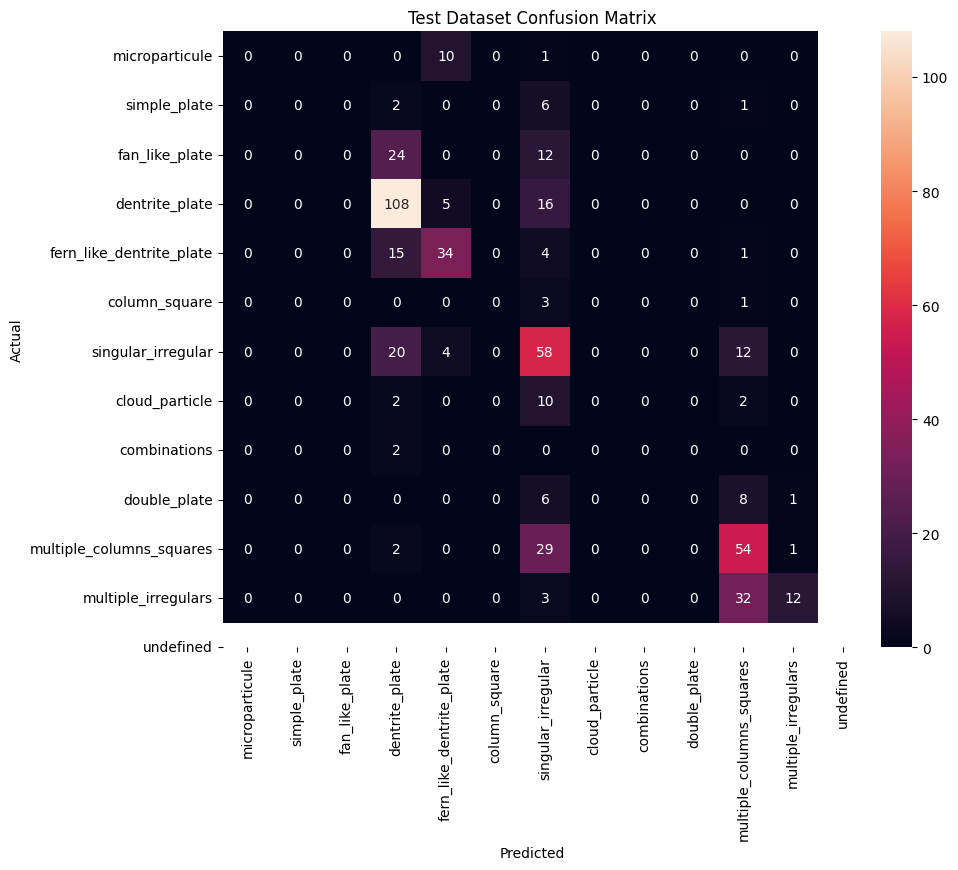

125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step

W0000 00:00:1722929510.679787   79378 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929510.681025   79378 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929510.682044   79378 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929510.683185   79378 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929510.684388   79378 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929510.685508   79378 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929510.686647   79378 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929510.687986   79378 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929510.689292   79378 gp

126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 210ms/step


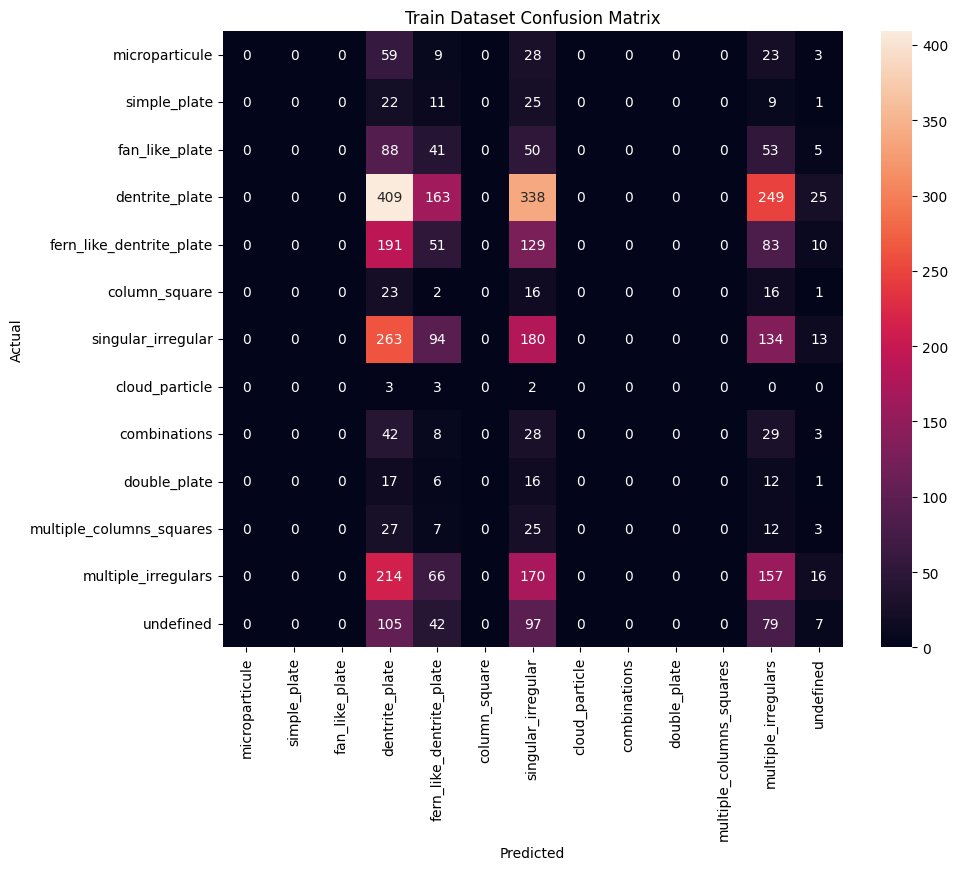

 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

2024-08-06 16:31:53.364878: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step


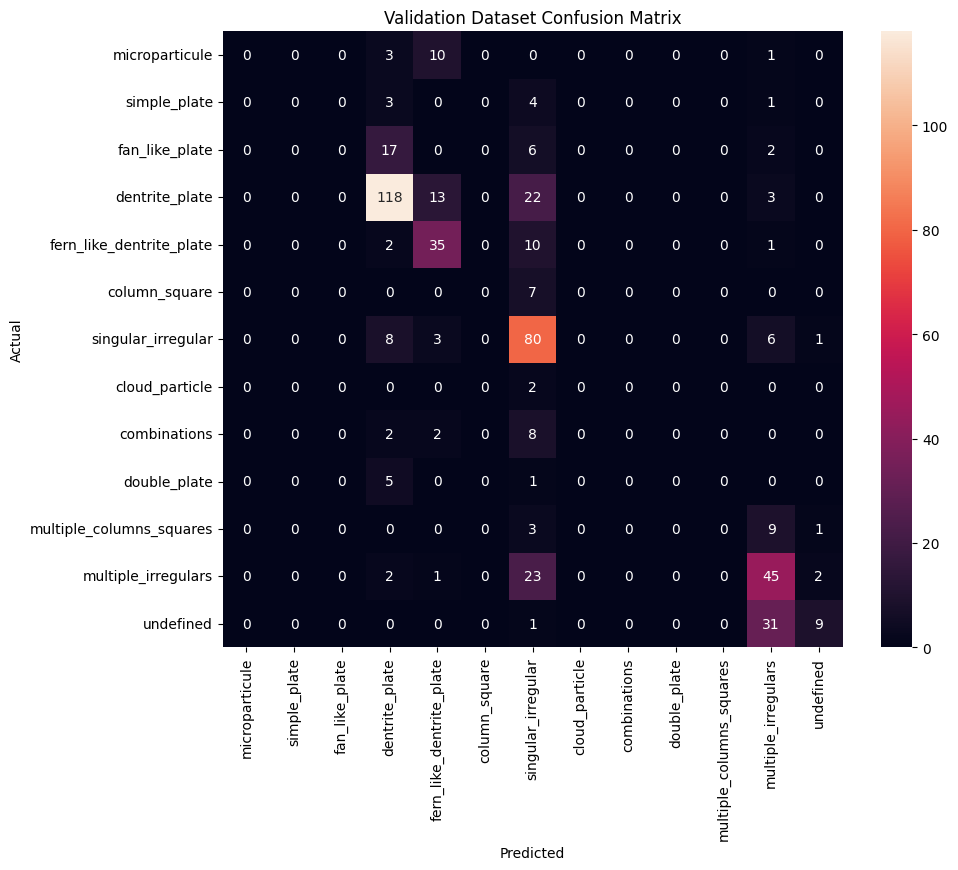

In [7]:
def confusion_matrix_plot(model, dataset, title):
    actual = [labels for _, labels in dataset.unbatch()]
    predicted = model.predict(dataset)

    actual = tf.stack(actual, axis=0)
    actual = tf.argmax(actual, axis=1)

    predicted = tf.concat(predicted, axis=0)
    predicted = tf.argmax(predicted, axis=1)

    # Plot the confusion matrix
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='g', xticklabels=label_names, yticklabels=label_names)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


confusion_matrix_plot(model, test_ds, "Test Dataset Confusion Matrix")
confusion_matrix_plot(model, train_ds, "Train Dataset Confusion Matrix")
confusion_matrix_plot(model, validation_ds, "Validation Dataset Confusion Matrix")

### Distribution

W0000 00:00:1722929566.183630   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929566.195044   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929566.201507   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929566.208147   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929566.214808   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929566.221886   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929566.228995   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929566.235970   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929566.242595   79383 gp

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


W0000 00:00:1722929567.194777   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929567.195706   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929567.196631   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929567.197730   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929567.198658   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929567.199575   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929567.200797   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929567.201920   79383 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1722929567.203147   79383 gp

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

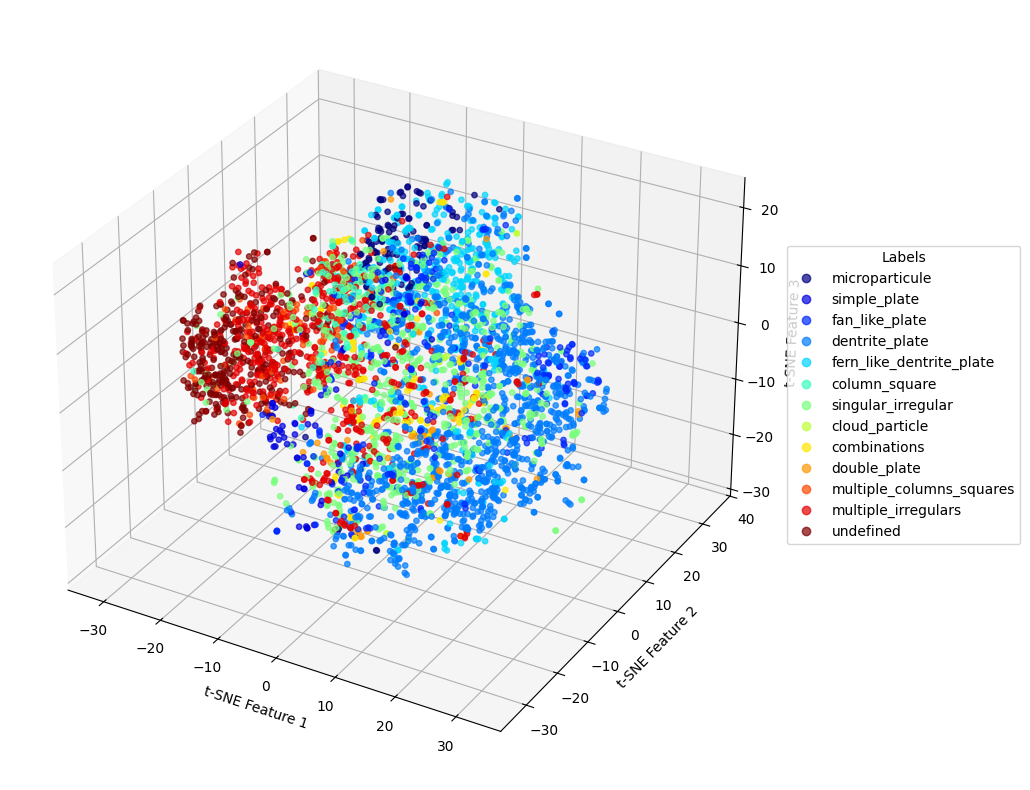

In [9]:
# Create a new model that outputs the features from the desired layer
feature_extraction_model = tf.keras.Model(inputs=model.input, outputs=global_max_layer.output)

# Extract features from the dataset
features = []
labels = []

for images, label in train_ds.unbatch():
    features.append(feature_extraction_model.predict(np.expand_dims(images, axis=0)))
    labels.append(np.argmax(label))

features = np.squeeze(np.array(features))
labels = np.array(labels)

# Apply t-SNE
tsne = TSNE(n_components=3, random_state=42)
tsne_features = tsne.fit_transform(features)

# Plot the t-SNE features
num_classes = metadata.features['label'].num_classes
bounds = np.linspace(0, num_classes, num_classes + 1)
cmap = plt.cm.jet
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
get_label_name = metadata.features['label'].int2str

fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(tsne_features[:, 0], tsne_features[:, 1], tsne_features[:, 2], c=labels, cmap=cmap, alpha=0.7, norm=norm, s=15)
ax.legend(handles=scatter.legend_elements()[0], labels=[get_label_name(i) for i in range(num_classes)], title="Labels", loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xlabel('t-SNE Feature 1')
ax.set_ylabel('t-SNE Feature 2')
ax.set_zlabel('t-SNE Feature 3')

plt.show()